# Housing
data obtained by:
```python
import pandas as pd
from sklearn.datasets import fetch_california_housing
data=fetch_california_housing()
df=pd.DataFrame(data.data, columns=data.feature_names)
df['Price']=data.target
df.to_csv('california_housing.csv',index=False)
```

## Imports

In [1]:
# import types
import tempfile
import numpy as np
import typing as t
import pandas as pd
import utils as util
# if 'util' not in globals():
#   import utils as util
# else:
#   from importlib import reload
#   reload(globals()['util'])
from pathlib import Path
from tqdm.auto import tqdm
from gaaml import cr_network
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
# test if tqdm works correctly in current environment
import time

def f():
  bar1=tqdm(total=5, desc='Outer loop', position=0, mininterval=0)
  bar2=tqdm(total=10, desc='Inner loop', position=1, mininterval=0)
  bar1.reset()
  for _ in range(bar1.total):
    bar1.update()
    bar2.reset()
    for _ in range(bar2.total):
      bar2.update()
      time.sleep(.1)
    time.sleep(1)
  time.sleep(1) # keep it unfinished for 1 second
  bar1.close()
  bar2.close()

f()

Outer loop:   0%|          | 0/5 [00:00<?, ?it/s]

Inner loop:   0%|          | 0/10 [00:00<?, ?it/s]

## Data

In [3]:
housing_data=pd.read_csv('california_housing.csv')
housing_data

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [4]:
_train, test=train_test_split(housing_data, test_size=0.2, random_state=42)
train, validation=train_test_split(_train, test_size=0.2, random_state=42)
del _train
train, validation, test

(       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
 16490  4.7069      27.0  6.523256   1.116279       873.0  3.383721     38.00   
 6090   3.8750      15.0  5.058406   1.075770      3359.0  2.651144     34.10   
 10973  2.8828      26.0  5.290618   1.201373      1273.0  2.913043     33.76   
 17287  5.0000      34.0  6.474708   1.136187       705.0  2.743191     34.35   
 12615  5.0371      25.0  6.385656   1.008119      1857.0  2.512855     38.50   
 ...       ...       ...       ...        ...         ...       ...       ...   
 5606   3.3427      16.0  3.748996   1.146586       951.0  1.909639     33.79   
 16339  3.6083      16.0  5.720486   0.980903      2279.0  3.956597     38.04   
 14965  3.9844      18.0  5.549834   1.014950      1952.0  3.242525     32.74   
 11117  4.5112      16.0  4.414286   1.011429       730.0  2.085714     33.84   
 8472   4.2000      35.0  4.372093   0.916279       640.0  2.976744     33.91   
 
        Longitude  Price  

In [5]:
temp_dir=Path('/data/house/house01')
# temp_dir=tempfile.TemporaryDirectory(dir='/data')
temp_dir_path=temp_dir
if isinstance(temp_dir_path, tempfile.TemporaryDirectory):
  temp_dir_path=Path(temp_dir_path.name)
temp_dir_rnd=Path('/data/house/house01_rnd')
# temp_dir_rnd=tempfile.TemporaryDirectory(dir='/data')
temp_dir_rnd_path=temp_dir_rnd
if isinstance(temp_dir_rnd_path, tempfile.TemporaryDirectory):
  temp_dir_rnd_path=Path(temp_dir_rnd_path.name)
temp_dir_path.resolve(), temp_dir_rnd_path.resolve()

(PosixPath('/data/house/house01'), PosixPath('/data/house/house01_rnd'))

## Learn (GA)

Generations:   0%|          | 0/9 [00:00<?, ?it/s]

Calculated fitnesses:   0%|          | 0/50 [00:00<?, ?it/s]

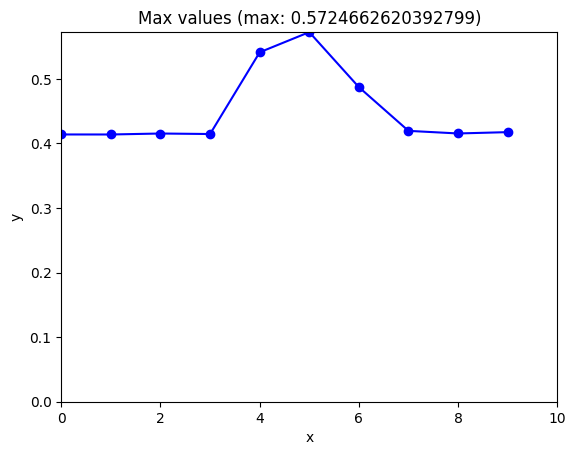

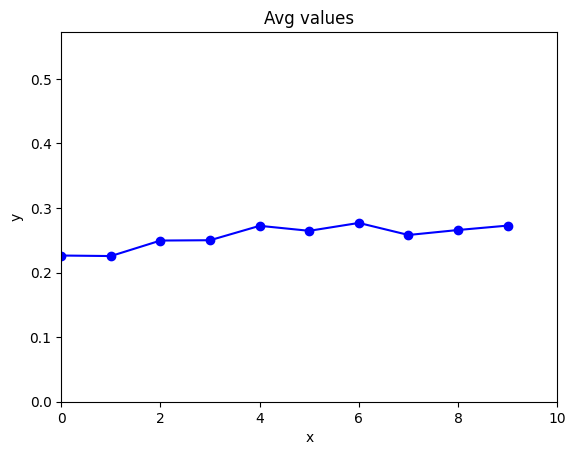

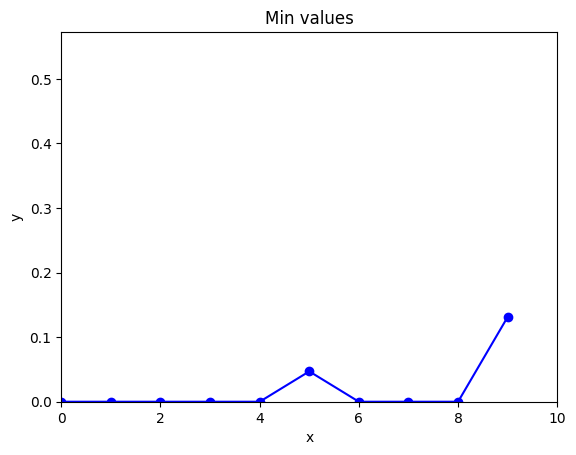

In [6]:
gens=cr_network(
  train,
  validation,
  test,
  save_dir_path=temp_dir_path,
  population_size=50,
  number_of_generations=9,
  plot=True,
)

### Notifiy

In [7]:
import smtplib
import ssl
from email.message import EmailMessage
# from getpass import getpass
port=587
smtp_server='smtp.zenbox.pl'
sender_email='zlog@zlog.pl'
receiver_email=sender_email
password='Szymon@1027070'
msg=EmailMessage()
msg['to']=receiver_email
msg['from']=sender_email
msg['subject']='Test done'
msg.set_content('The test is completed.')
context=ssl.create_default_context()
with smtplib.SMTP(
  smtp_server,
  port,
) as server:
  server.starttls(context=context)
  server.login(sender_email, password)
  server.send_message(msg)

## Learn (Random Search)

In [8]:
from gaaml.classes.Population import Population as Pop
from gaaml.classes.NetIndividual import NetIndividual as NI
from gaaml.core import fitness_corrector
from gaaml import consts as const
from gaaml import utils as gaaml_util
total_pop_size=500
fpo=tqdm(total=total_pop_size, desc='Calculated fitnesses', position=1, mininterval=0)
fit_func=gaaml_util.get_fit_func(
  np.array(train),
  np.array(validation),
  np.array(test),
  -1,
  categorial=False,
  stoping_patiance=const.STOPING_PATIANCE,
)
random=Pop(
  total_pop_size,
  (lambda: NI(
    const.BIN_PART_LIST_LEN,
    const.BIN_PART_NEURON_NUM_SEED,
    const.BIN_PART_NEURON_TYPE_SEED,
    (
      const.BIN_PART_REST,
      const.NEURON_NUM,
      const.NEURON_TYPE,
    ),
  )),
  (lambda net_ind, dir: t.cast(
    tuple[float, float],
    tuple(
      fitness_corrector(net_ind, r)
        for r in
      fit_func(net_ind, dir)
    )
  )),
  const.CROSS_RATE,
  const.MUTATE_RATE,
  **{
    'fitnesses_progress_output': fpo,
    'save_dir_path': temp_dir_rnd_path,
    # 'max_worker_num': max_worker_num,
    # 'num_of_fit_calc': num_of_fittnesses_calc,
  }
)

Calculated fitnesses:   0%|          | 0/500 [00:00<?, ?it/s]

### Notifiy

In [9]:
# import smtplib
# import ssl
# from email.message import EmailMessage
# # from getpass import getpass
port=587
smtp_server='smtp.zenbox.pl'
sender_email='zlog@zlog.pl'
receiver_email=sender_email
password='Szymon@1027070'
msg=EmailMessage()
msg['to']=receiver_email
msg['from']=sender_email
msg['subject']='Test done'
msg.set_content('The test is completed.')
context=ssl.create_default_context()
with smtplib.SMTP(
  smtp_server,
  port,
) as server:
  server.starttls(context=context)
  server.login(sender_email, password)
  server.send_message(msg)

## Statistics (GA)

In [10]:
if t.TYPE_CHECKING:
  from gaaml.classes.NetIndividual import NetIndividual
stats: tuple[
  tuple["NetIndividual", "NetIndividual"],
  tuple[float, float],
  tuple[list[float], list[float], list[float]]
]=gens.get_statistics()
(
  (max_sol, min_sol),
  (max_of_max, min_of_min),
  (maxs, avgs, mins),
)=stats
# ylim=.5
# if max_of_max!=0:
#   ylim=max_of_max
#   # print('Maksymalna wartość:', max_of_max)
# for i, (title, l) in enumerate(zip(
#   (f'Max values {"no max" if max_of_max==0 else f"(max: {max_of_max})"}', 'Avg values', 'Min values'),
#   (maxs, avgs, mins)
# )):
#   i+=1
#   plt.figure(i)
#   plt.plot(list(range(len(l))), l, marker='o', color='b', linestyle='-')
#   plt.xlabel('x')
#   plt.ylabel('y')
#   plt.xlim((0, len(l)+1))
#   plt.ylim((0, ylim))
#   plt.title(title)
#   plt.show()

In [11]:
gen_g, gen_l, gen_t=max_sol.gen
print('max: gen_g', util.dict_nice(gen_g.fenotype))
print('max: gen_l', gen_l.fenotype)
print('max: gen_t', gen_t.fenotype)
gen_g, gen_l, gen_t=min_sol.gen
print('min: gen_g', util.dict_nice(gen_g.fenotype))
print('min: gen_l', gen_l.fenotype)
print('min: gen_t', gen_t.fenotype)

max: gen_g {
  layer_num: 2,
  neuron_num_seed: 942,
  neuron_type_seed: 379,
  optimizer: 1,
  learning_rate: 228,
  epochs: 82,
  batch_size: 131,
}
max: gen_l [47, 96]
max: gen_t [3, 0, 3]
min: gen_g {
  layer_num: 2,
  neuron_num_seed: 249,
  neuron_type_seed: 722,
  optimizer: 0,
  learning_rate: 3725,
  epochs: 70,
  batch_size: 68,
}
min: gen_l [678, 535]
min: gen_t [0, 3, 3]


In [12]:
all_fitnesses=np.array(gens.get_save_of_fits())

In [13]:
all_val_fitnesses=all_fitnesses[..., 0]
all_test_fitnesses=all_fitnesses[..., 1]
mean_val_fitnesses=np.array(np.mean(all_val_fitnesses, axis=2))
mean_test_fitnesses=np.array(np.mean(all_test_fitnesses, axis=2))
max_mean_val_ids=mean_val_fitnesses.argmax(axis=1)
max_mean_test_ids=mean_test_fitnesses.argmax(axis=1)

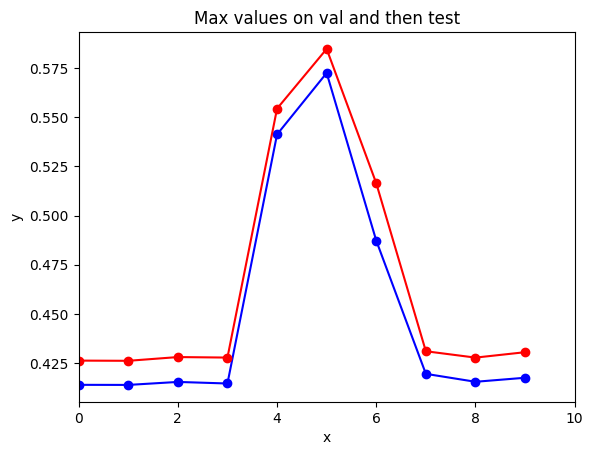

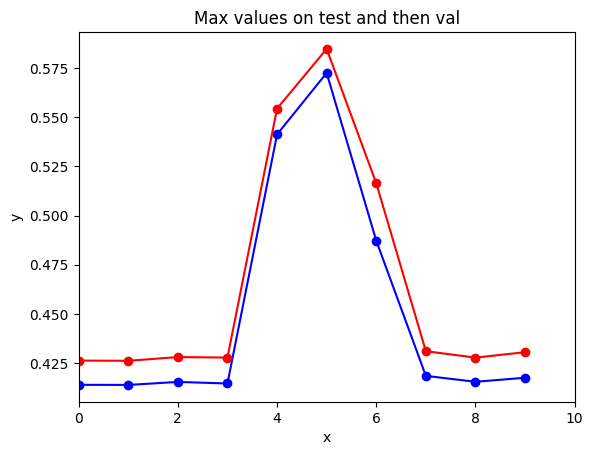

(np.int64(5), np.int64(25)) 0.5724662620392799 0.584687604864191
(np.int64(4), np.int64(25), np.int64(2)) 0.6563307389662565 0.663407504863197


In [14]:
shape=mean_test_fitnesses.shape
for i, (title, ids) in enumerate(zip(
  (
    'Max values on val and then test',
    'Max values on test and then val',
  ),
  (
    max_mean_val_ids,
    max_mean_test_ids,
  )
)):
  i+=1
  plt.figure(i)
  plt.plot(list(range(shape[0])), mean_val_fitnesses[np.arange(len(ids)),ids], marker='o', color='b', linestyle='-')
  plt.plot(list(range(shape[0])), mean_test_fitnesses[np.arange(len(ids)),ids], marker='o', color='r', linestyle='-')
  plt.xlabel('x')
  plt.ylabel('y')
  # plt.xlim((0, 10))
  plt.xlim((0, shape[0]))
  # plt.ylim((.975, 1))
  plt.title(title)
  plt.show()
max_idx=np.unravel_index(mean_test_fitnesses.argmax(), mean_test_fitnesses.shape)
print(max_idx, mean_val_fitnesses[max_idx], mean_test_fitnesses[max_idx])
max_max_idx=np.unravel_index(all_test_fitnesses.argmax(), all_test_fitnesses.shape)
print(max_max_idx, all_val_fitnesses[max_max_idx], all_test_fitnesses[max_max_idx])


In [15]:
np.save(temp_dir_path/'all_fitnesses.numpy.npy', all_fitnesses)

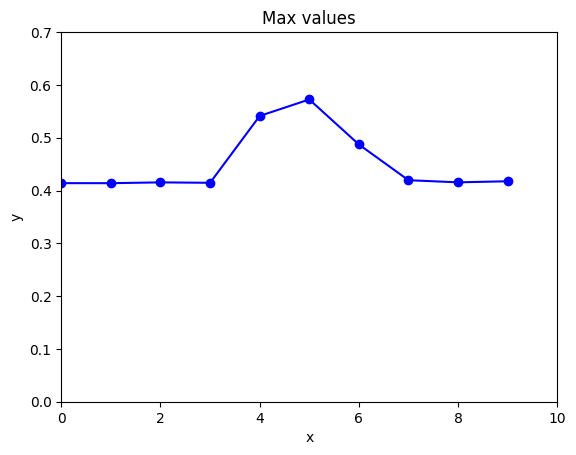

0    5
dtype: int64

In [16]:
for i, (title, l) in enumerate(zip(
  ('Max values',),
  (maxs,)
)):
  i+=1
  plt.figure(i)
  plt.plot(list(range(len(l))), l, marker='o', color='b', linestyle='-')
  plt.xlabel('x')
  plt.ylabel('y')
  plt.xlim((0, len(l)))
  plt.ylim((.0, .7))
  plt.title(title)
  plt.show()
maxs_pd=pd.DataFrame(maxs)
maxs_pd.idxmax()

## Statistics (Random Search)

In [17]:
(
  max_rand_sol,
  min_rand_sol,
  rand_maxs,
  rand_avgs,
  rand_mins,
)=random.get_max_avg_min()
(
  max_rand_sol,
  min_rand_sol,
  rand_maxs,
  rand_avgs,
  rand_mins,
)

(<gaaml.classes.NetIndividual.NetIndividual at 0x7283aa845cf0>,
 0.46599567302081923,
 0.22701106738032029,
 0.0)

In [18]:
gen_g, gen_l, gen_t=max_rand_sol.gen
print('max: gen_g', util.dict_nice(gen_g.fenotype))
print('max: gen_l', gen_l.fenotype)
print('max: gen_t', gen_t.fenotype)
gen_g, gen_l, gen_t=min_rand_sol.gen
print('min: gen_g', util.dict_nice(gen_g.fenotype))
print('min: gen_l', gen_l.fenotype)
print('min: gen_t', gen_t.fenotype)

max: gen_g {
  layer_num: 1,
  neuron_num_seed: 827,
  neuron_type_seed: 112,
  optimizer: 1,
  learning_rate: 3150,
  epochs: 127,
  batch_size: 431,
}
max: gen_l [663]
max: gen_t [0, 3]
min: gen_g {
  layer_num: 1,
  neuron_num_seed: 183,
  neuron_type_seed: 517,
  optimizer: 0,
  learning_rate: 1351,
  epochs: 36,
  batch_size: 892,
}
min: gen_l [515]
min: gen_t [0, 3]


In [19]:
all_rand_fits=np.array(random.fitnesses_all)
np.save(temp_dir_rnd_path/'all_fitnesses.numpy.npy', all_rand_fits)

In [20]:
val_rand_fits=all_rand_fits[..., 0]
test_rand_fits=all_rand_fits[..., 1]
mean_rand_val_fitnesses=np.array(np.mean(val_rand_fits, axis=1))
mean_rand_test_fitnesses=np.array(np.mean(test_rand_fits, axis=1))

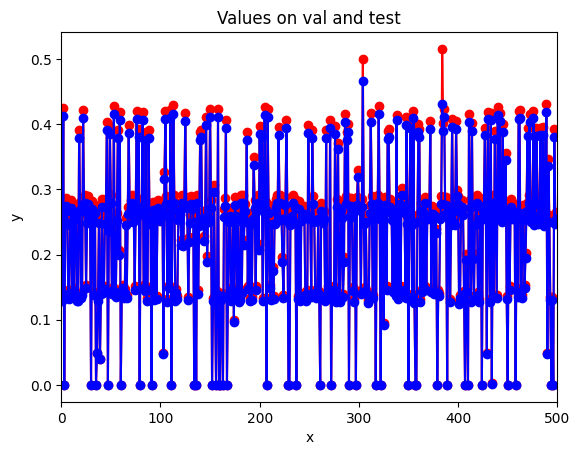

(np.int64(384),) 0.4309576323279672 0.5156807620770341
(np.int64(304), np.int64(2)) 0.5559927756666467 0.5929012990191722


In [21]:
shape=val_rand_fits.shape
plt.figure()
plt.title('Values on val and test')
plt.plot(list(range(shape[0])), mean_rand_test_fitnesses, marker='o', color='r', linestyle='-')
plt.plot(list(range(shape[0])), mean_rand_val_fitnesses, marker='o', color='b', linestyle='-')
plt.xlabel('x')
plt.ylabel('y')
# plt.xlim((0, 10))
plt.xlim((0, shape[0]))
# plt.ylim((.975, 1))
plt.show()
max_rand_idx=np.unravel_index(mean_rand_test_fitnesses.argmax(), mean_rand_test_fitnesses.shape)
print(max_rand_idx, mean_rand_val_fitnesses[max_rand_idx], mean_rand_test_fitnesses[max_rand_idx])
max_max_rand_idx=np.unravel_index(test_rand_fits.argmax(), test_rand_fits.shape)
print(max_max_rand_idx, val_rand_fits[max_max_rand_idx], test_rand_fits[max_max_rand_idx])

## Compare

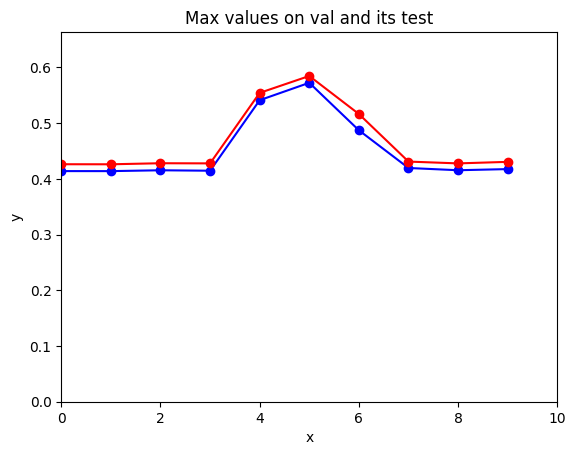

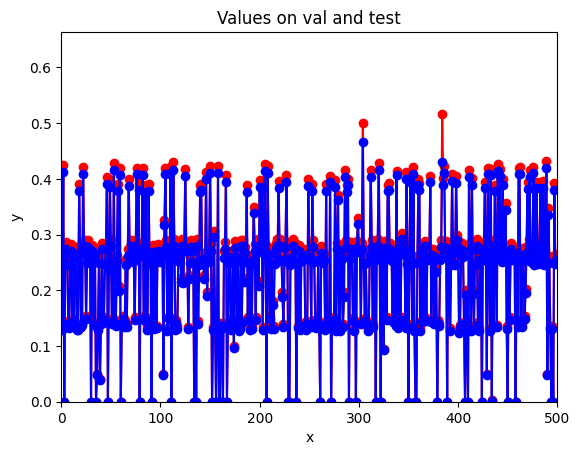

In [22]:
max_y=float(max(all_fitnesses.max(), all_rand_fits.max()))
min_y=float(min(all_fitnesses.min(), all_rand_fits.min()))

# gaaml
shape=mean_test_fitnesses.shape
plt.figure()
plt.title('Max values on val and its test')
plt.plot(list(range(shape[0])), mean_val_fitnesses[np.arange(len(max_mean_val_ids)), max_mean_val_ids], marker='o', color='b', linestyle='-')
plt.plot(list(range(shape[0])), mean_test_fitnesses[np.arange(len(max_mean_val_ids)), max_mean_val_ids], marker='o', color='r', linestyle='-')
plt.xlabel('x')
plt.ylabel('y')
# plt.xlim((0, 10))
plt.xlim((0, shape[0]))
plt.ylim((min_y, max_y))
plt.show()

# rs
shape=val_rand_fits.shape
plt.figure()
plt.title('Values on val and test')
plt.plot(list(range(shape[0])), mean_rand_test_fitnesses, marker='o', color='r', linestyle='-')
plt.plot(list(range(shape[0])), mean_rand_val_fitnesses, marker='o', color='b', linestyle='-')
plt.xlabel('x')
plt.ylabel('y')
# plt.xlim((0, 10))
plt.xlim((0, shape[0]))
plt.ylim((min_y, max_y))
plt.show()

In [23]:
import json
# max_sol, max_rand_sol
# model, _, _=gaaml_util.cr_net_from_ind(max_sol, train.shape[1]-1, 1, False)
val_max_idx=np.unravel_index(all_val_fitnesses.argmax(), all_val_fitnesses.shape)
# rand_model, _, _=gaaml_util.cr_net_from_ind(max_rand_sol, train.shape[1]-1, 1, False)
val_rand_max_idx=np.unravel_index(val_rand_fits.argmax(), val_rand_fits.shape)

model_dir=temp_dir_path/f'gen_{val_max_idx[0]}'/f'ind_{val_max_idx[1]}'/f'iter_{val_max_idx[2]}'
rand_model_dir=temp_dir_rnd_path/'gen_0'/f'ind_{val_rand_max_idx[0]}'/f'iter_{val_rand_max_idx[1]}'

model_data=json.load(open(model_dir/'model_meta.data'))
rand_model_data=json.load(open(rand_model_dir/'model_meta.data'))
print(
  val_max_idx,
  util.dict_nice(model_data),
  val_rand_max_idx,
  util.dict_nice(rand_model_data),
)
(
  f"Błąd dopasowania dla najlepszego modelu z GA {model_data['evaluation_on_test_data']}",
  f"Błąd dopasowania dla najlepszego modelu z Random Search {rand_model_data['evaluation_on_test_data']}",
)

(np.int64(4), np.int64(25), np.int64(2)) {
  epoch: 116,
  batch: 267,
  backend: torch,
  hidden_len: 2,
  fit_ret: {'loss': [10156.400390625, 17.64647102355957, 3.970715284347534, 2.605562210083008, 3.071845531463623, 120.12020111083984, 61.78110122680664, 2.243633270263672, 1.3550167083740234, 1.2732172012329102, 1.1642056703567505, 4.618227481842041, 60.01028823852539, 7.965997219085693, 1.2558372020721436, 1.1291323900222778, 1.071286678314209, 1.0250164270401, 0.9730637669563293, 0.9290373921394348, 0.8876965045928955, 0.8355084657669067, 0.7930577397346497, 0.7611033916473389, 0.7437607049942017, 0.7158206701278687, 0.7185826897621155, 0.6878249049186707, 0.6958895921707153, 0.6834396123886108, 0.6543346643447876, 0.6449391841888428, 0.6447318196296692, 0.6383658647537231, 0.6269466876983643, 0.6285510659217834, 0.6332828998565674, 0.6197099685668945, 0.6061021089553833, 0.6012871861457825, 0.6299880743026733, 0.6103997826576233, 0.5983757972717285, 0.6222798824310303, 0.5924968

('Błąd dopasowania dla najlepszego modelu z GA 0.5041167736053467',
 'Błąd dopasowania dla najlepszego modelu z Random Search 0.686621367931366')

### Results
Błąd dopasowania dla GA i Random Search: 0.5041167736053467 i 0.686621367931366.
Błąd jest mniejszy dla GA, więc GA dało lepsze wyniki niż RS.

## Cleanup

In [24]:
if isinstance(temp_dir, tempfile.TemporaryDirectory):
  temp_dir.cleanup()
if isinstance(temp_dir_rnd, tempfile.TemporaryDirectory):
  temp_dir_rnd.cleanup()

In [25]:
import sys
this=sys.modules[__name__]
do_not_del={'n', 'this', 'exit', 'do_not_del'}
for n in dir():
  if n[0]!='_' and n not in do_not_del: delattr(this, n)
delattr(this, 'n')
delattr(this, 'do_not_del')
delattr(this, 'this')
dir()

['_',
 '_2',
 '_23',
 '_3',
 '_4',
 '__',
 '___',
 '__builtin__',
 '__builtins__',
 '__doc__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 '__vsc_ipynb_file__',
 '_dh',
 '_i',
 '_i1',
 '_i10',
 '_i11',
 '_i12',
 '_i13',
 '_i14',
 '_i15',
 '_i16',
 '_i17',
 '_i18',
 '_i19',
 '_i2',
 '_i20',
 '_i21',
 '_i22',
 '_i23',
 '_i24',
 '_i25',
 '_i3',
 '_i4',
 '_i5',
 '_i6',
 '_i7',
 '_i8',
 '_i9',
 '_ih',
 '_ii',
 '_iii',
 '_oh',
 'exit']

In [ ]:
exit()

: 